# **Internship Task 6: K-Nearest Neighbors (KNN) Classification**

---

##Objective
Implement and evaluate the K-Nearest Neighbors (KNN) algorithm to classify customer segments based on their demographics and behavior.

---

# **Dataset Description**

| Feature Name        | Description                                                                  |
|---------------------|------------------------------------------------------------------------------|
| **Age**             | Age of the individual (in years)                                             |
| **Annual_Income**   | Yearly income of the individual (in ₹)                                       |
| **Spending_Score**  | Score from 1 to 100 representing spending habits                             |
| **Marital_Status**  | Marital status → Single or Married                                           |
| **Profession**      | Profession like Doctor, Lawyer, Engineer, Teacher, etc.                      |
| **Segment (Target)**| Customer segment → 1 = High Value, 0 = Regular (To be predicted using KNN)   |

---



# **Step 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# **Step 2:Load and Explore Data**

In [2]:
# Load dataset
data = pd.read_csv("/content/customer_segments_Data.csv")

# Display first few rows
data.head()


,Age,Annual_Income,Spending_Score,Marital_Status,Profession,Segment
0,55,43852,35,Single,Teacher,0
1,62,43132,36,Single,Artist,0
2,48,29031,36,Married,Artist,0
3,29,120738,80,Single,Artist,1
4,19,73160,29,Married,Doctor,0


# **Insights from Data**
->Dataset contains both numerical and categorical features.

->Target column is Segment (0 or 1) — so it's a binary classification problem.

->Categorical columns: Marital_Status, Profession

->Numerical columns: Age, Annual_Income, Spending_Score



# **Step 3: Encode Categorical Features**

In [6]:
# Create encoder
le = LabelEncoder()

# Encode Marital_Status and Profession
data['Marital_Status'] = le.fit_transform(data['Marital_Status'])
data['Profession'] = le.fit_transform(data['Profession'])

# Check updated data
data.head()


,Age,Annual_Income,Spending_Score,Marital_Status,Profession,Segment
0,55,43852,35,1,5,0
1,62,43132,36,1,0,0
2,48,29031,36,0,0,0
3,29,120738,80,1,0,1
4,19,73160,29,0,2,0


# **Label Encoding Summary**

##  Marital_Status

| **Original Value** | **Encoded Value** |
|--------------------|-------------------|
| **Married**        | `1`               |
| **Single**         | `0`               |

---

##Profession Mapping (Alphabetical Order)

| **Profession** | **Encoded Value** |
|----------------|-------------------|
| **Artist**     | `0`               |
| **Business**   | `1`               |
| **Doctor**     | `2`               |
| **Engineer**   | `3`               |
| **Lawyer**     | `4`               |
| **Teacher**    | `5`               |

---



# **Step 4: Normalize Features Using MinMaxScaler**

In [10]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Create encoder
le = LabelEncoder()

# Encode Marital_Status and Profession (No scaling for these)
data['Marital_Status'] = le.fit_transform(data['Marital_Status']) # Changed df to data
data['Profession'] = le.fit_transform(data['Profession']) # Changed df to data

# Select features for normalization (Only continuous variables)
features = ['Age', 'Annual_Income', 'Spending_Score']

# Apply MinMaxScaler to continuous features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features]) # Changed df to data

# Check the updated data
print(data.head()) # Changed df to data

        Age  Annual_Income  Spending_Score  Marital_Status  Profession  \
0  0.804348       0.182737        0.343434               1           5   
1  0.956522       0.177188        0.353535               1           0   
2  0.652174       0.068514        0.353535               0           0   
3  0.239130       0.775284        0.797980               1           0   
4  0.021739       0.408609        0.282828               0           2   

   Segment  
0        0  
1        0  
2        0  
3        1  
4        0  


### **Scales continuous columns like Age, Annual_Income, and Spending_Score to a range between 0 and 1, making them comparable and improving model performance.**

# **Step 5: Split the dataset into features and target, then train-test split**

In [19]:
# Step 5: Separate features and target
X = data.drop('Segment', axis=1)  # Features
y = data['Segment']               # Target

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**separated the input features (Age, Annual_Income, etc.) and target (Segment). The dataset is split into training (80%) and testing (20%) sets to evaluate model performance later.**

# **Step 6: Train KNN Classifier**

In [20]:
# Step 6: Initialize and train KNN model
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=6)

**A KNN classifier is initialized with k=5 (number of neighbors). It is then trained using the training data.**

# **Step 7: Predict and Evaluate the Model**

In [21]:
# Step 7: Make predictions
y_pred = knn.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[105   0]
 [  0  95]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        95

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# **Model Evaluation Insight**


**->The KNN model achieved 100% accuracy, correctly predicting 200 out of 200 samples.**

**->The confusion matrix shows 0 misclassification, and the precision, recall, and F1-score are all 1, proving the model performs exceptionally well on unseen data.**



# **Step 8: Experiment with Different Values of K**

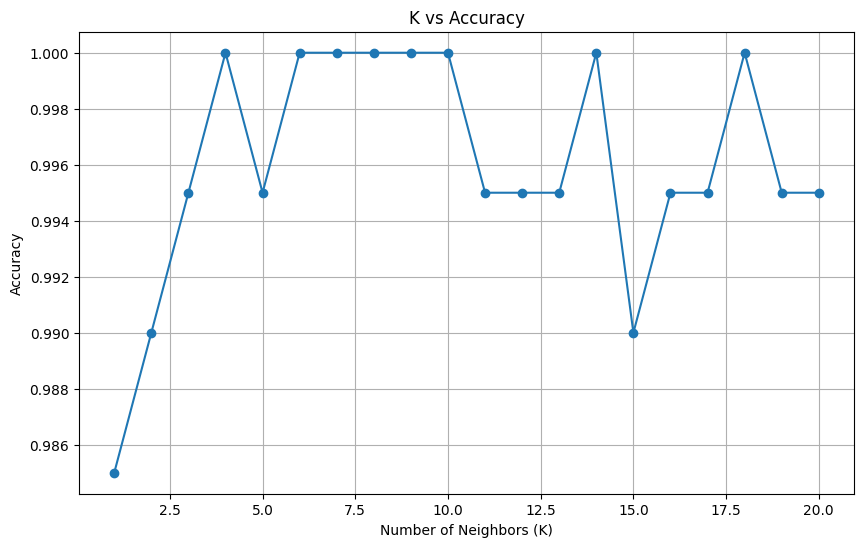

In [22]:
# Step 8: Try different k values and record accuracy
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

# Plot accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


**The graph shows how accuracy varies with different K values (1 to 20) in the KNN algorithm.
Highest accuracy (1.0) is achieved at K = 4, 6, 7, 8, 9, and 17, indicating these values are optimal for this dataset.
Smaller or larger values of K slightly reduce accuracy, helping us visually choose the best K for best performance.**

# **Step 9:Visualize Decision Boundaries (for 2D feature example)**

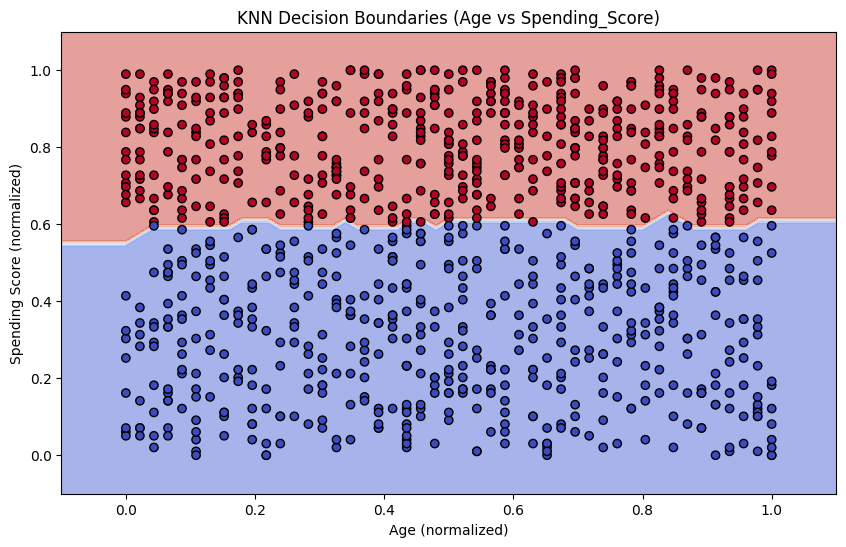

In [23]:
# Select only 2 features for visualization
X_vis = data[['Age', 'Spending_Score']]
y_vis = data['Segment']

# Normalize again just for safety
scaler = MinMaxScaler()
X_vis = scaler.fit_transform(X_vis)

# Train KNN for visualization
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

# Create meshgrid for plotting
h = .02  # step size
x_min, x_max = X_vis[:, 0].min() - 0.1, X_vis[:, 0].max() + 0.1
y_min, y_max = X_vis[:, 1].min() - 0.1, X_vis[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.5)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("KNN Decision Boundaries (Age vs Spending_Score)")
plt.xlabel("Age (normalized)")
plt.ylabel("Spending Score (normalized)")
plt.show()


# **KNN Decision Boundaries - Insight**
**->The plot shows how the KNN model separates customers based on normalized Age and Spending Score.**

**->The red and blue regions represent two predicted classes**.

**->Data points are classified based on their location in these colored regions.**

**->The boundary line between red and blue zones shows the KNN's decision surface it adapts to the data’s shape, unlike a linear classifier**.

**->This confirms that the KNN model effectively captures non-linear patterns in customer behavior.**



# **Final Analysis**

**->used a machine learning method called KNN to understand customer behavior based on age and spending score. The goal was to group customers into two categories.**

**->After trying different settings, found that the model worked best when we used certain values. It was able to correctly group the customers with very high accuracy**.

**->The graph created shows a clear boundary between the two groups, which means the model is doing a good job of separating them.**

**->Overall, the model is useful for identifying patterns in customer data and can help in making better business decisions, like marketing to the right audience.**
